# Sprint 3 — Evaluación y visualización de baselines

    Consolida métricas, gaps train-vs-CV y ranking.

In [5]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.io_utils import load_kick_data, save_df
from src.preprocessing import prepare_features, split_X_y

pd.set_option('display.max_columns', 120)
print('Proyecto:', PROJECT_ROOT)

Proyecto: /Users/alexandralozano/dp261-g1


In [6]:
results = pd.read_csv(REPORTS_DIR / "baseline_cv_results.csv")

metric_cols = [
    "model",
    "recall_cv_mean",
    "f2_cv_mean",
    "precision_cv_mean",
    "f1_cv_mean",
    "f05_cv_mean",
    "roc_auc_cv_mean",
    "average_precision_cv_mean"
]

display(
    results[metric_cols]
    .sort_values(
        ["recall_cv_mean", "f2_cv_mean", "precision_cv_mean"],
        ascending=[False, False, False]
    )
)

,model,recall_cv_mean,f2_cv_mean,precision_cv_mean,f1_cv_mean,f05_cv_mean,roc_auc_cv_mean,average_precision_cv_mean
0,DecisionTree,0.347154,0.337769,0.304994,0.324648,0.312550,0.618047,0.186297
1,LinearSVM,0.261382,0.299204,0.712861,0.382222,0.529340,0.755643,0.446534
2,LogisticRegression,0.250813,0.288854,0.737390,0.373998,0.530694,0.757379,0.447457
3,GradientBoosting,0.246748,0.287131,0.832756,0.380578,0.564339,0.765190,0.472366
4,HistGradientBoosting,0.245935,0.286951,0.863707,0.382712,0.574578,0.765440,0.479953
5,RandomForest,0.230488,0.270392,0.880477,0.365257,0.562769,0.751203,0.458945
6,KNN,0.011789,0.014656,0.547273,0.023074,0.054220,0.655096,0.217129
7,Dummy_most_frequent,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.123000


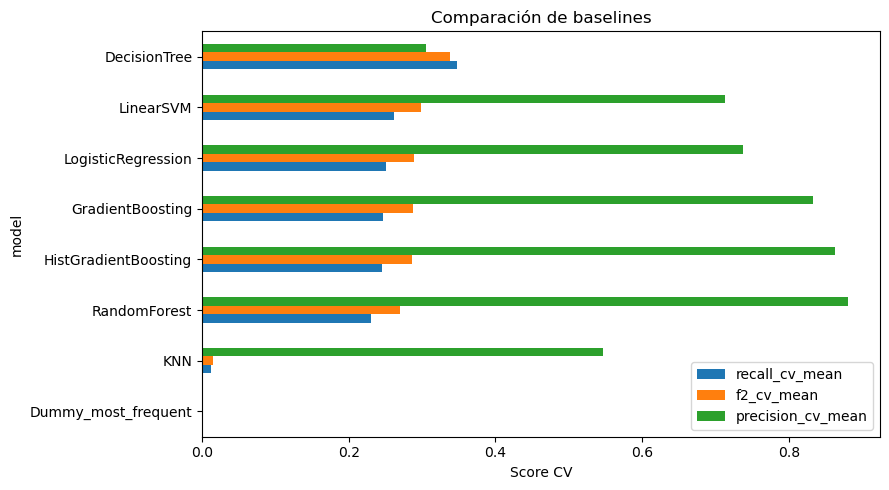

In [7]:
plot_df = results[results['status'].eq('ok')].set_index('model')[['recall_cv_mean','f2_cv_mean','precision_cv_mean']]
ax = plot_df.sort_values('recall_cv_mean').plot(kind='barh', figsize=(9, 5))
ax.set_title('Comparación de baselines')
ax.set_xlabel('Score CV')
plt.tight_layout()
plt.show()

In [8]:
gap_cols = [c for c in results.columns if c.endswith('_gap')]
display(results[['model'] + gap_cols].sort_values('recall_gap', ascending=False, na_position='last').head(10))

,model,accuracy_gap,precision_gap,recall_gap,f1_gap,f05_gap,f2_gap,roc_auc_gap,average_precision_gap
5,RandomForest,0.098450,0.119523,0.769106,0.634539,0.437149,0.729283,0.248797,0.541055
0,DecisionTree,0.177700,0.695006,0.652846,0.675352,0.687450,0.662231,0.381953,0.813703
4,HistGradientBoosting,0.006937,0.072541,0.036992,0.051721,0.065667,0.041837,0.148721,0.252007
3,GradientBoosting,0.004625,0.056849,0.021748,0.031876,0.043788,0.024930,0.050102,0.084733
6,KNN,0.001687,0.219184,0.010366,0.019972,0.044930,0.012835,0.158915,0.149299
2,LogisticRegression,0.000900,0.010509,0.003659,0.005704,0.008147,0.004289,0.020889,0.022645
1,LinearSVM,0.000175,0.002811,0.000610,0.001325,0.002198,0.000821,0.021399,0.021585
7,Dummy_most_frequent,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
